In [2]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
COLS = [
    "gis_pin", "mod_iv_county_name",
    "property_location",
    "ST_ADDRESS", "CITY_STATE", "ZIP5",
    "census_tract_geoid", "pct_seasonal",
]

df = pq.read_table(
    "data/parcels_shore.parquet",
    filters=[("mod_iv_year", "==", 2023)],
    columns=COLS,
).to_pandas()

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 442,588  |  Columns: 8


,gis_pin,mod_iv_county_name,property_location,ST_ADDRESS,CITY_STATE,ZIP5,census_tract_geoid,pct_seasonal
0,0108_1124_14,ATLANTIC,28 ROBIN ROAD,28 ROBIN ROAD,"EGG HARBOR TOWNSHIP, NJ",08234,34001011702,0.0
1,0108_1124_16,ATLANTIC,22 IDLEWOOD AVENUE,22 IDLEWOOD AVE,"EGG HARBOR TWP, NJ",08234,34001011702,0.0
2,0108_1124_17,ATLANTIC,18 IDLEWOOD AVENUE,18 IDLEWOOD AVENUE,"EGG HARBOR TOWNSHIP, NJ",08234,34001011702,0.0


In [4]:
# Collapse long-form street type words to standard abbreviations before comparing,
# so "SAILFISH DRIVE" and "SAILFISH DR" compare as equal.
_ABBREV = {
    "STREET": "ST", "AVENUE": "AVE", "BOULEVARD": "BLVD",
    "DRIVE": "DR", "ROAD": "RD", "COURT": "CT", "LANE": "LN",
    "PLACE": "PL", "CIRCLE": "CIR", "TERRACE": "TER",
    "HIGHWAY": "HWY", "PARKWAY": "PKWY", "TRAIL": "TRL",
    "NORTH": "N", "SOUTH": "S", "EAST": "E", "WEST": "W",
}
# Strip unit designators and everything after them
_UNIT_PAT = re.compile(r"\b(APT|UNIT|STE|SUITE|#)\b.*", re.I)

def normalize_addr(s):
    if not isinstance(s, str) or not s.strip():
        return ""
    s = _UNIT_PAT.sub("", s.upper())
    s = re.sub(r"[^\w\s]", " ", s)        # remove punctuation
    words = [_ABBREV.get(w, w) for w in s.split()]
    return " ".join(words).strip()

# Spot-check
examples = ["512 Lagoon Blvd", "512 LAGOON BOULEVARD", "207 Linden Ave.", "207 LINDEN AVENUE APT 3"]
for e in examples:
    print(f"{e!r:45s} → {normalize_addr(e)!r}")

'512 Lagoon Blvd'                             → '512 LAGOON BLVD'
'512 LAGOON BOULEVARD'                        → '512 LAGOON BLVD'
'207 Linden Ave.'                             → '207 LINDEN AVE'
'207 LINDEN AVENUE APT 3'                     → '207 LINDEN AVE'


In [5]:
df["prop_norm"] = df["property_location"].map(normalize_addr)
df["mail_norm"] = df["ST_ADDRESS"].map(normalize_addr)

# Flag 1: normalized street address matches exactly
df["addr_match"] = (df["prop_norm"] == df["mail_norm"]) & (df["prop_norm"] != "")

# Flag 2: owner mailing state is not NJ
df["out_of_state"] = ~df["CITY_STATE"].str.upper().str.strip().str.endswith(", NJ")

# Flag 3: absentee owner — address differs OR out-of-state
df["is_absentee"] = ~df["addr_match"] | df["out_of_state"]

df[["property_location", "prop_norm", "ST_ADDRESS", "mail_norm",
    "CITY_STATE", "addr_match", "out_of_state", "is_absentee"]].sample(5, random_state=42)

,property_location,prop_norm,ST_ADDRESS,mail_norm,CITY_STATE,addr_match,out_of_state,is_absentee
422532,344 STEPHAN AVENUE,344 STEPHAN AVE,344 STEPHAN AVENUE,344 STEPHAN AVE,TOMS RIVER NJ,True,True,True
440227,206 W 21ST AVE,206 W 21ST AVE,206 W 21ST AVE,206 W 21ST AVE,"NORTH WILDWOOD, NJ",True,False,False
43344,239 FORGE ROAD,239 FORGE RD,239 FORGE ROAD,239 FORGE RD,WEST CREEK NJ,True,True,True
303390,31 YORKWOOD DR.,31 YORKWOOD DR,31 YORKWOOD DRIVE,31 YORKWOOD DR,BRICK NJ,True,True,True
204475,12 CYPRESS STREET,12 CYPRESS ST,12 CYPRESS STREET,12 CYPRESS ST,"HAZLET, NJ",True,False,False


In [6]:
n = len(df)
print(f"=== Overall statistics (2023, n={n:,}) ===")
print(f"Address match (normalized exact):  {df['addr_match'].sum():>8,}  ({df['addr_match'].mean():.1%})")
print(f"Address mismatch:                  {(~df['addr_match']).sum():>8,}  ({(~df['addr_match']).mean():.1%})")
print(f"Out-of-state mailing address:      {df['out_of_state'].sum():>8,}  ({df['out_of_state'].mean():.1%})")
print(f"Absentee owner (either flag):      {df['is_absentee'].sum():>8,}  ({df['is_absentee'].mean():.1%})")
print()

print("=== By county ===")
county_stats = (
    df.groupby("mod_iv_county_name")
    .agg(
        n=("gis_pin", "count"),
        pct_addr_match=("addr_match", "mean"),
        pct_out_of_state=("out_of_state", "mean"),
        pct_absentee=("is_absentee", "mean"),
    )
    .assign(
        pct_addr_match=lambda d: d["pct_addr_match"].map("{:.1%}".format),
        pct_out_of_state=lambda d: d["pct_out_of_state"].map("{:.1%}".format),
        pct_absentee=lambda d: d["pct_absentee"].map("{:.1%}".format),
    )
)
print(county_stats.to_string())
print()

print("=== Sample: address match ===")
print(df[df["addr_match"]][["property_location", "ST_ADDRESS", "CITY_STATE"]].head(4).to_string(index=False))
print()
print("=== Sample: address mismatch, in-state ===")
mask_mismatch_nj = ~df["addr_match"] & ~df["out_of_state"]
print(df[mask_mismatch_nj][["property_location", "ST_ADDRESS", "CITY_STATE"]].head(4).to_string(index=False))
print()
print("=== Sample: out-of-state owner ===")
print(df[df["out_of_state"]][["property_location", "ST_ADDRESS", "CITY_STATE"]].head(4).to_string(index=False))

=== Overall statistics (2023, n=442,588) ===
Address match (normalized exact):   272,310  (61.5%)
Address mismatch:                   170,278  (38.5%)
Out-of-state mailing address:       246,834  (55.8%)
Absentee owner (either flag):       306,325  (69.2%)

=== By county ===
                         n pct_addr_match pct_out_of_state pct_absentee
mod_iv_county_name                                                     
ATLANTIC             65986          54.4%            23.4%        48.8%
BURLINGTON              31          51.6%            12.9%        51.6%
CAPE MAY             72667          31.1%            42.1%        69.6%
CUMBERLAND             109          55.0%            98.2%        99.1%
MIDDLESEX             2433          85.3%            99.6%        99.7%
MONMOUTH             96243          74.9%            14.5%        32.4%
OCEAN               205119          68.1%            89.9%        92.6%

=== Sample: address match ===
 property_location         ST_ADDRESS        

In [7]:
# Top states owners mail from (excluding NJ)
top_states = (
    df[df["out_of_state"]]["CITY_STATE"]
    .str.upper().str.strip()
    .str.extract(r",\s*([A-Z]{2})$")[0]
    .value_counts()
    .head(12)
    .rename("parcels")
    .rename_axis("state")
    .reset_index()
    .assign(pct=lambda d: (d["parcels"] / df["out_of_state"].sum()).map("{:.1%}".format))
)
print("Top out-of-state mailing states (% of all out-of-state parcels):")
print(top_states.to_string(index=False))

Top out-of-state mailing states (% of all out-of-state parcels):
state  parcels   pct
   PA    31049 12.6%
   NY     6116  2.5%
   NJ     4151  1.7%
   FL     3157  1.3%
   MD     1199  0.5%
   DE     1038  0.4%
   VA      631  0.3%
   CT      500  0.2%
   CA      496  0.2%
   TX      332  0.1%
   SC      203  0.1%
   NC      200  0.1%


In [8]:
tract = (
    df.groupby("census_tract_geoid")
    .agg(
        n_parcels=("gis_pin", "count"),
        absentee_rate=("is_absentee", "mean"),
        out_of_state_rate=("out_of_state", "mean"),
        addr_mismatch_rate=("addr_match", lambda x: (~x).mean()),
        pct_seasonal=("pct_seasonal", "first"),
    )
    .dropna(subset=["pct_seasonal"])
    .reset_index()
)
print(f"Census tracts with both measures: {len(tract):,}")
tract.describe().round(3)

Census tracts with both measures: 300


,n_parcels,absentee_rate,out_of_state_rate,addr_mismatch_rate,pct_seasonal
count,300.000,300.000,300.000,300.000,300.000
mean,1466.707,0.639,0.486,0.364,0.136
std,894.622,0.310,0.383,0.246,0.210
min,17.000,0.035,0.000,0.035,0.000
25%,815.750,0.360,0.104,0.162,0.003
50%,1356.000,0.677,0.470,0.301,0.031
75%,1969.500,0.948,0.906,0.522,0.190
max,5205.000,1.000,1.000,0.999,0.807


In [9]:
metrics = [
    ("absentee_rate",      "Absentee rate\n(addr mismatch OR out-of-state)"),
    ("out_of_state_rate",  "Out-of-state mailing rate"),
    ("addr_mismatch_rate", "Address mismatch rate\n(normalized exact)"),
]

for col, _ in metrics:
    r_p, p_p = stats.pearsonr(tract[col], tract["pct_seasonal"])
    r_s, p_s = stats.spearmanr(tract[col], tract["pct_seasonal"])
    print(f"{col:<22}  Pearson r={r_p:+.3f} (p={p_p:.2e})   Spearman ρ={r_s:+.3f} (p={p_s:.2e})")

absentee_rate           Pearson r=+0.299 (p=1.33e-07)   Spearman ρ=+0.243 (p=2.14e-05)
out_of_state_rate       Pearson r=+0.186 (p=1.22e-03)   Spearman ρ=+0.207 (p=3.12e-04)
addr_mismatch_rate      Pearson r=+0.704 (p=2.85e-46)   Spearman ρ=+0.586 (p=4.73e-29)


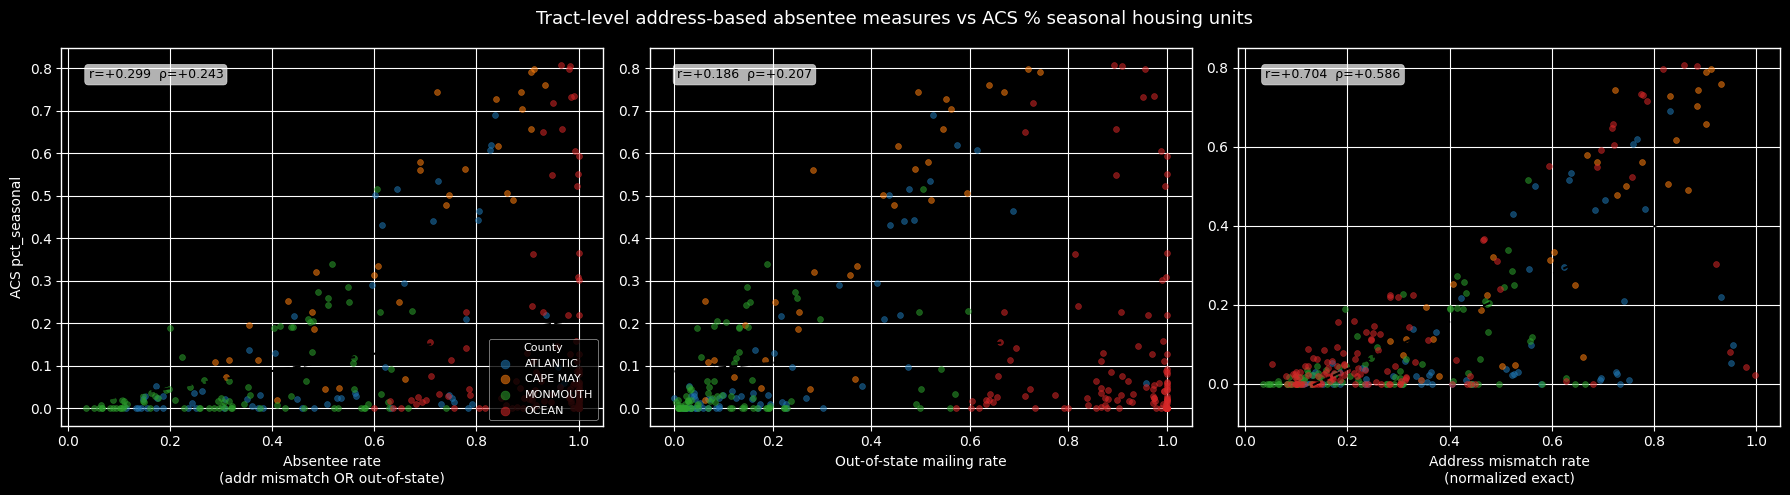

In [10]:
COUNTY_PALETTE = {
    "ATLANTIC": "#1f77b4",
    "CAPE MAY": "#ff7f0e",
    "MONMOUTH": "#2ca02c",
    "OCEAN":    "#d62728",
}

# Attach county to tract via the first parcel's county in the group
tract_county = (
    df[["census_tract_geoid", "mod_iv_county_name"]]
    .drop_duplicates("census_tract_geoid")
    .rename(columns={"mod_iv_county_name": "county"})
    .assign(county=lambda d: d["county"].str.upper())
)
tract = tract.merge(tract_county, on="census_tract_geoid", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tract-level address-based absentee measures vs ACS % seasonal housing units", fontsize=13)

for ax, (col, ylabel) in zip(axes, metrics):
    r_p, p_p = stats.pearsonr(tract[col], tract["pct_seasonal"])
    r_s, p_s = stats.spearmanr(tract[col], tract["pct_seasonal"])

    for county, grp in tract.groupby("county"):
        color = COUNTY_PALETTE.get(county, "#888888")
        ax.scatter(grp[col], grp["pct_seasonal"], alpha=0.55, s=18,
                   color=color, label=county)

    # OLS regression line
    m, b, *_ = stats.linregress(tract[col], tract["pct_seasonal"])
    x_line = np.linspace(tract[col].min(), tract[col].max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", lw=1.5, ls="--")

    ax.set_xlabel(ylabel, fontsize=10)
    ax.set_ylabel("ACS pct_seasonal" if ax is axes[0] else "", fontsize=10)
    ax.text(0.05, 0.92, f"r={r_p:+.3f}  ρ={r_s:+.3f}", transform=ax.transAxes,
            fontsize=9, color="black",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

axes[0].legend(title="County", fontsize=8, title_fontsize=8,
               loc="lower right", markerscale=1.5)
plt.tight_layout()
plt.show()